# NSL-KDD Unsupervised Anomaly Detection - Part 2: Preprocessing & Feature Engineering

**Goal:** Transform raw features into ML-ready format for unsupervised learning

**In This Notebook:**
1. Load preprocessed data from Notebook 1
2. Encode categorical features
3. Feature scaling & normalization
4. Variance-based feature selection
5. Correlation-based feature reduction
6. Create final feature set for unsupervised learning
7. Save preprocessed data

**Key Principle:** We use labels ONLY for interpretation/evaluation, NOT for training!

---
## 1. Setup & Data Loading

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import zscore

# Plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load the data from Notebook 1
df = pd.read_csv('nslkdd_train_with_categories.csv')

print(f"✓ Data loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}...")  # Show first 10 columns

✓ Data loaded: (125973, 44)
Columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot']...


In [3]:
# Load feature information
with open('feature_info.json', 'r') as f:
    feature_info = json.load(f)

categorical_features = feature_info['categorical_features']
numerical_features = feature_info['numerical_features']
binary_features = feature_info['binary_features']

print(f"✓ Categorical features: {len(categorical_features)}")
print(f"✓ Numerical features: {len(numerical_features)}")
print(f"✓ Binary features: {len(binary_features)}")

✓ Categorical features: 3
✓ Numerical features: 38
✓ Binary features: 5


---
## 2. Categorical Feature Encoding

We have 3 categorical features:
- **protocol_type**: 3 values (tcp, udp, icmp)
- **service**: 70 values (http, ftp, smtp, etc.)
- **flag**: 11 values (SF, S0, REJ, etc.)

**Strategy:**
- Label Encoding for low-cardinality features (protocol_type, flag)
- One-Hot Encoding OR Label Encoding for service (70 categories is borderline)

Let's try **Label Encoding** first to avoid dimensionality explosion

In [4]:
# Create a copy for preprocessing
df_processed = df.copy()

# Separate labels for later (we won't use them in training)
labels = df_processed['attack_category'].copy()
attack_types = df_processed['attack_type'].copy()

print(f"Labels separated: {labels.shape}")
print(f"Attack types separated: {attack_types.shape}")

Labels separated: (125973,)
Attack types separated: (125973,)


### Label Encoding for Categorical Features

In [5]:
# Initialize label encoders dictionary
label_encoders = {}

print("Encoding categorical features...\n")
print("=" * 80)

for feature in categorical_features:
    print(f"\n{feature.upper()}:")
    print(f"Unique values before: {df_processed[feature].nunique()}")
    print(f"Sample values: {df_processed[feature].unique()[:5]}")
    
    # Create and fit label encoder
    le = LabelEncoder()
    df_processed[feature] = le.fit_transform(df_processed[feature])
    label_encoders[feature] = le
    
    print(f"Encoded range: {df_processed[feature].min()} to {df_processed[feature].max()}")
    print(f"Mapping sample: {dict(list(zip(le.classes_[:3], le.transform(le.classes_[:3]))))}")

print("\n" + "=" * 80)
print("✓ All categorical features encoded successfully!")

Encoding categorical features...


PROTOCOL_TYPE:
Unique values before: 3
Sample values: ['tcp' 'udp' 'icmp']
Encoded range: 0 to 2
Mapping sample: {'icmp': np.int64(0), 'tcp': np.int64(1), 'udp': np.int64(2)}

SERVICE:
Unique values before: 70
Sample values: ['ftp_data' 'other' 'private' 'http' 'remote_job']
Encoded range: 0 to 69
Mapping sample: {'IRC': np.int64(0), 'X11': np.int64(1), 'Z39_50': np.int64(2)}

FLAG:
Unique values before: 11
Sample values: ['SF' 'S0' 'REJ' 'RSTR' 'SH']
Encoded range: 0 to 10
Mapping sample: {'OTH': np.int64(0), 'REJ': np.int64(1), 'RSTO': np.int64(2)}

✓ All categorical features encoded successfully!


In [6]:
# Check the data types after encoding
print("Data types after encoding:")
print(df_processed[categorical_features].dtypes)

Data types after encoding:
protocol_type    int64
service          int64
flag             int64
dtype: object


---
## 3. Feature Selection - Part 1: Low Variance Filter

Remove features with very low variance (provide little information)

In [7]:
# Get all feature columns (exclude labels and difficulty)
feature_columns = [col for col in df_processed.columns 
                   if col not in ['attack_type', 'attack_category', 'difficulty_level']]

print(f"Total features to analyze: {len(feature_columns)}")

# Calculate variance for each feature
variances = df_processed[feature_columns].var().sort_values()

print("\nFeatures with lowest variance:")
print(variances.head(10))

Total features to analyze: 41

Features with lowest variance:
num_outbound_cmds    0.000000
is_host_login        0.000008
land                 0.000198
urgent               0.000206
num_shells           0.000492
root_shell           0.001340
su_attempted         0.002039
num_failed_logins    0.002047
is_guest_login       0.009334
num_access_files     0.009874
dtype: float64


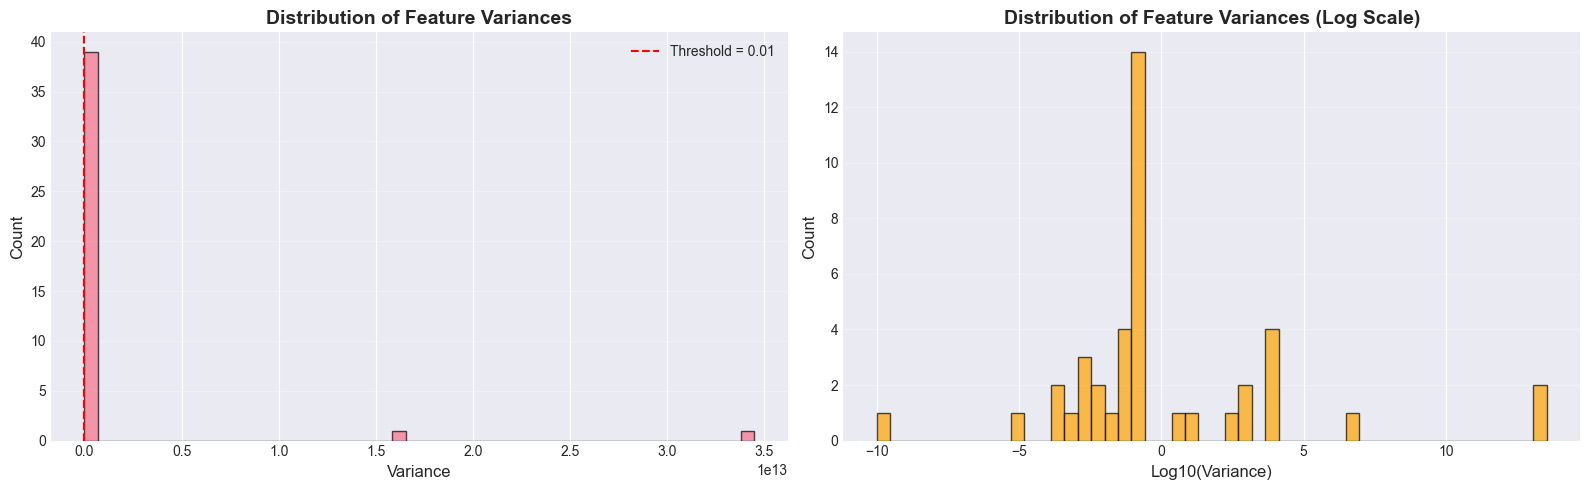

In [8]:
# Visualize variance distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of variances
axes[0].hist(variances, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Variance', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Distribution of Feature Variances', fontsize=14, fontweight='bold')
axes[0].axvline(0.01, color='red', linestyle='--', label='Threshold = 0.01')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Log scale histogram
axes[1].hist(np.log10(variances + 1e-10), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Log10(Variance)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Distribution of Feature Variances (Log Scale)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Apply variance threshold (remove features with variance < 0.01)
variance_threshold = 0.01

low_variance_features = variances[variances < variance_threshold].index.tolist()

print(f"Features with variance < {variance_threshold}:")
print(f"Count: {len(low_variance_features)}")
print(f"\nFeatures to remove:")
for feat in low_variance_features:
    print(f"  - {feat:30s} | Variance: {variances[feat]:.6f}")

# Note: We'll keep track but remove later after correlation analysis
print(f"\n⚠ Will consider removing these {len(low_variance_features)} features after correlation analysis")

Features with variance < 0.01:
Count: 10

Features to remove:
  - num_outbound_cmds              | Variance: 0.000000
  - is_host_login                  | Variance: 0.000008
  - land                           | Variance: 0.000198
  - urgent                         | Variance: 0.000206
  - num_shells                     | Variance: 0.000492
  - root_shell                     | Variance: 0.001340
  - su_attempted                   | Variance: 0.002039
  - num_failed_logins              | Variance: 0.002047
  - is_guest_login                 | Variance: 0.009334
  - num_access_files               | Variance: 0.009874

⚠ Will consider removing these 10 features after correlation analysis


---
## 4. Feature Selection - Part 2: Correlation Analysis

Identify and remove highly correlated features (redundancy)

In [10]:
# Calculate correlation matrix for all features
print("Computing correlation matrix...")
correlation_matrix = df_processed[feature_columns].corr()

print(f"✓ Correlation matrix computed: {correlation_matrix.shape}")

Computing correlation matrix...
✓ Correlation matrix computed: (41, 41)


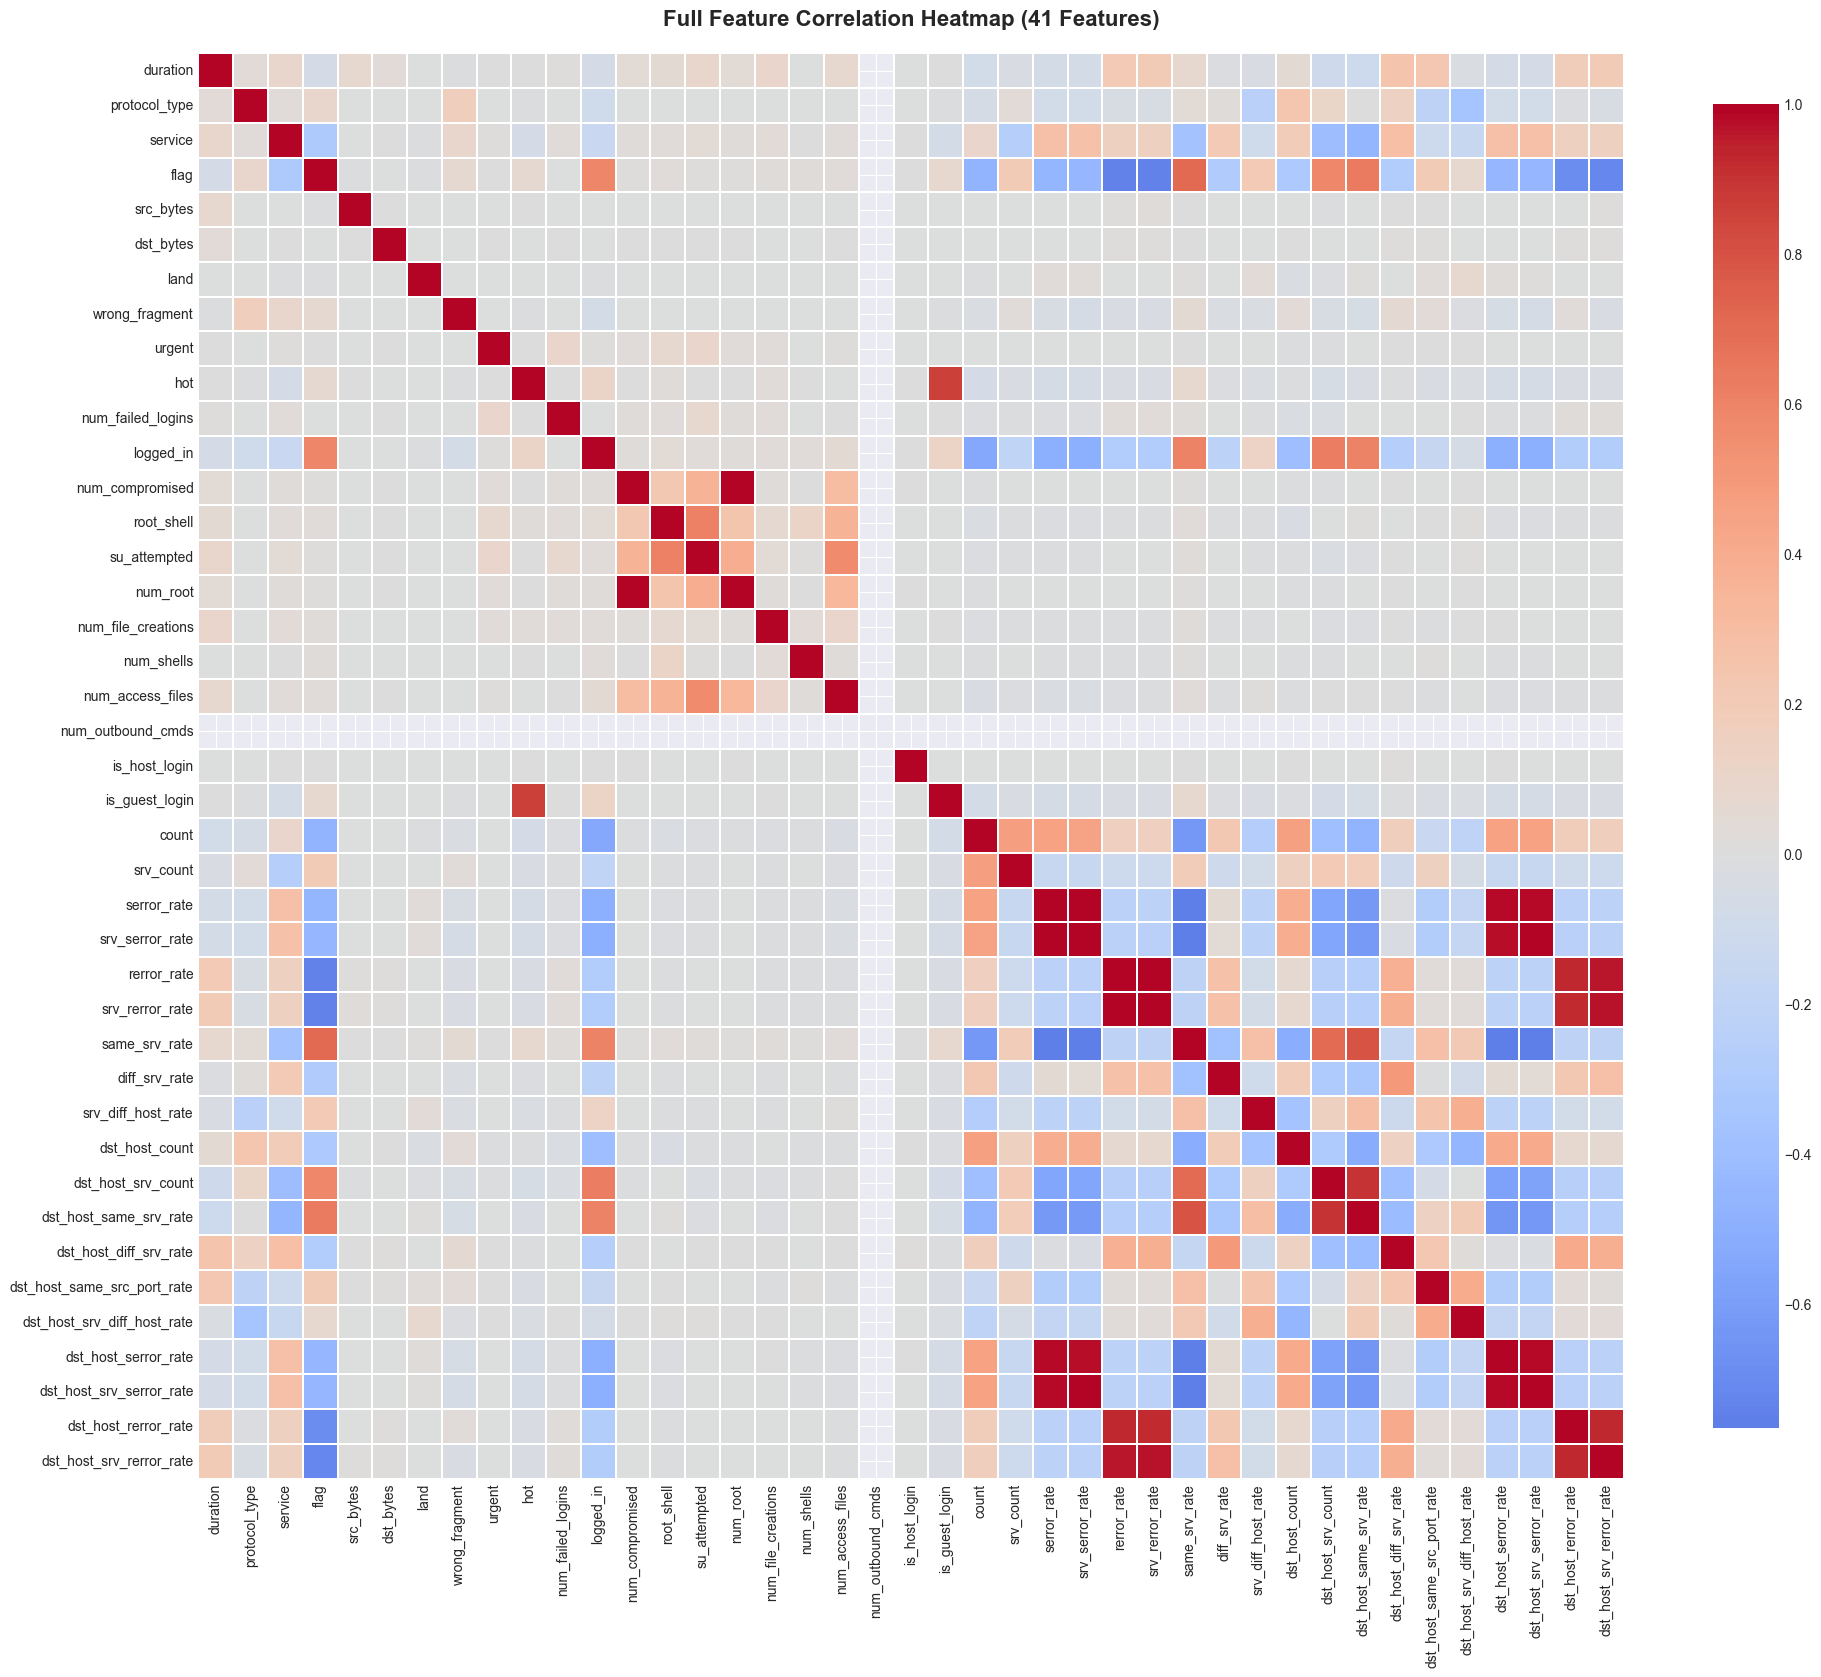

In [11]:
# Visualize correlation matrix (full)
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.1, cbar_kws={"shrink": 0.8})
plt.title('Full Feature Correlation Heatmap (41 Features)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [12]:
# Find highly correlated feature pairs
high_corr_threshold = 0.90

print(f"Finding feature pairs with |correlation| > {high_corr_threshold}...")
print("=" * 80)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > high_corr_threshold:
            high_corr_pairs.append((
                correlation_matrix.columns[i], 
                correlation_matrix.columns[j], 
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print(f"\nFound {len(high_corr_pairs)} highly correlated pairs:\n")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{feat1:30s} <-> {feat2:30s} | r = {corr:7.4f}")
else:
    print(f"No feature pairs with |r| > {high_corr_threshold}")

print("\n" + "=" * 80)

Finding feature pairs with |correlation| > 0.9...

Found 13 highly correlated pairs:

num_compromised                <-> num_root                       | r =  0.9988
serror_rate                    <-> srv_serror_rate                | r =  0.9933
rerror_rate                    <-> srv_rerror_rate                | r =  0.9890
srv_serror_rate                <-> dst_host_srv_serror_rate       | r =  0.9863
dst_host_serror_rate           <-> dst_host_srv_serror_rate       | r =  0.9851
serror_rate                    <-> dst_host_srv_serror_rate       | r =  0.9811
serror_rate                    <-> dst_host_serror_rate           | r =  0.9794
srv_serror_rate                <-> dst_host_serror_rate           | r =  0.9776
srv_rerror_rate                <-> dst_host_srv_rerror_rate       | r =  0.9702
rerror_rate                    <-> dst_host_srv_rerror_rate       | r =  0.9644
rerror_rate                    <-> dst_host_rerror_rate           | r =  0.9267
dst_host_rerror_rate           <->

In [13]:
# Function to identify features to remove based on correlation
def get_correlated_features_to_remove(corr_matrix, threshold=0.90):
    """
    Identify one feature from each highly correlated pair to remove.
    Keep the feature with higher variance.
    """
    to_remove = set()
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                feat1 = corr_matrix.columns[i]
                feat2 = corr_matrix.columns[j]
                
                # Keep feature with higher variance
                var1 = df_processed[feat1].var()
                var2 = df_processed[feat2].var()
                
                if var1 < var2:
                    to_remove.add(feat1)
                else:
                    to_remove.add(feat2)
    
    return list(to_remove)

# Get features to remove
correlated_features_to_remove = get_correlated_features_to_remove(correlation_matrix, threshold=high_corr_threshold)

print(f"Features to remove due to high correlation (|r| > {high_corr_threshold}):")
print(f"Count: {len(correlated_features_to_remove)}")
for feat in correlated_features_to_remove:
    print(f"  - {feat}")

Features to remove due to high correlation (|r| > 0.9):
Count: 7
  - dst_host_srv_rerror_rate
  - dst_host_rerror_rate
  - rerror_rate
  - dst_host_serror_rate
  - serror_rate
  - num_compromised
  - dst_host_srv_serror_rate


---
## 5. Combine Feature Selection Criteria

In [14]:
# Combine both removal lists
all_features_to_remove = list(set(low_variance_features + correlated_features_to_remove))

print("=" * 80)
print("FEATURE REMOVAL SUMMARY")
print("=" * 80)
print(f"\nLow variance features: {len(low_variance_features)}")
print(f"Highly correlated features: {len(correlated_features_to_remove)}")
print(f"Total unique features to remove: {len(all_features_to_remove)}")
print(f"\nFeatures to remove:")
for feat in sorted(all_features_to_remove):
    reason = []
    if feat in low_variance_features:
        reason.append("low variance")
    if feat in correlated_features_to_remove:
        reason.append("high correlation")
    print(f"  - {feat:30s} | Reason: {', '.join(reason)}")

print(f"\nFeatures before removal: {len(feature_columns)}")
print(f"Features after removal: {len(feature_columns) - len(all_features_to_remove)}")
print("=" * 80)

FEATURE REMOVAL SUMMARY

Low variance features: 10
Highly correlated features: 7
Total unique features to remove: 17

Features to remove:
  - dst_host_rerror_rate           | Reason: high correlation
  - dst_host_serror_rate           | Reason: high correlation
  - dst_host_srv_rerror_rate       | Reason: high correlation
  - dst_host_srv_serror_rate       | Reason: high correlation
  - is_guest_login                 | Reason: low variance
  - is_host_login                  | Reason: low variance
  - land                           | Reason: low variance
  - num_access_files               | Reason: low variance
  - num_compromised                | Reason: high correlation
  - num_failed_logins              | Reason: low variance
  - num_outbound_cmds              | Reason: low variance
  - num_shells                     | Reason: low variance
  - rerror_rate                    | Reason: high correlation
  - root_shell                     | Reason: low variance
  - serror_rate           

In [15]:
# Remove features
features_to_keep = [f for f in feature_columns if f not in all_features_to_remove]

print(f"\n✓ Keeping {len(features_to_keep)} features for analysis")
print(f"\nFeatures retained:")
for i, feat in enumerate(features_to_keep, 1):
    print(f"{i:2d}. {feat}")


✓ Keeping 24 features for analysis

Features retained:
 1. duration
 2. protocol_type
 3. service
 4. flag
 5. src_bytes
 6. dst_bytes
 7. wrong_fragment
 8. hot
 9. logged_in
10. num_root
11. num_file_creations
12. count
13. srv_count
14. srv_serror_rate
15. srv_rerror_rate
16. same_srv_rate
17. diff_srv_rate
18. srv_diff_host_rate
19. dst_host_count
20. dst_host_srv_count
21. dst_host_same_srv_rate
22. dst_host_diff_srv_rate
23. dst_host_same_src_port_rate
24. dst_host_srv_diff_host_rate


---
## 6. Feature Scaling

We'll create multiple scaled versions for different algorithms:
1. **StandardScaler**: For PCA, K-Means (assumes normal distribution)
2. **MinMaxScaler**: For distance-based algorithms 
3. **RobustScaler**: For algorithms sensitive to outliers

In [16]:
# Extract feature matrix (without labels)
X = df_processed[features_to_keep].values

print(f"Feature matrix shape: {X.shape}")
print(f"Sample statistics before scaling:")
print(f"  Mean: {X.mean():.4f}")
print(f"  Std: {X.std():.4f}")
print(f"  Min: {X.min():.4f}")
print(f"  Max: {X.max():.4f}")

Feature matrix shape: (125973, 24)
Sample statistics before scaling:
  Mean: 2753.5357
  Std: 1452487.5844
  Min: 0.0000
  Max: 1379963888.0000


### StandardScaler (Z-score normalization)

In [17]:
# StandardScaler: (X - mean) / std
scaler_standard = StandardScaler()
X_scaled_standard = scaler_standard.fit_transform(X)

print("StandardScaler applied:")
print(f"  Mean: {X_scaled_standard.mean():.6f}")
print(f"  Std: {X_scaled_standard.std():.6f}")
print(f"  Min: {X_scaled_standard.min():.4f}")
print(f"  Max: {X_scaled_standard.max():.4f}")

StandardScaler applied:
  Mean: -0.000000
  Std: 1.000000
  Min: -2.5954
  Max: 325.7486


### MinMaxScaler (0-1 range)

In [18]:
# MinMaxScaler: (X - min) / (max - min)
scaler_minmax = MinMaxScaler()
X_scaled_minmax = scaler_minmax.fit_transform(X)

print("MinMaxScaler applied:")
print(f"  Mean: {X_scaled_minmax.mean():.4f}")
print(f"  Std: {X_scaled_minmax.std():.4f}")
print(f"  Min: {X_scaled_minmax.min():.4f}")
print(f"  Max: {X_scaled_minmax.max():.4f}")

MinMaxScaler applied:
  Mean: 0.2286
  Std: 0.3676
  Min: 0.0000
  Max: 1.0000


### RobustScaler (robust to outliers)

In [19]:
# RobustScaler: (X - median) / IQR
scaler_robust = RobustScaler()
X_scaled_robust = scaler_robust.fit_transform(X)

print("RobustScaler applied:")
print(f"  Mean: {X_scaled_robust.mean():.4f}")
print(f"  Std: {X_scaled_robust.std():.4f}")
print(f"  Min: {X_scaled_robust.min():.4f}")
print(f"  Max: {X_scaled_robust.max():.4f}")

RobustScaler applied:
  Mean: 20.7860
  Std: 4654.7375
  Min: -2.2500
  Max: 4999869.0000


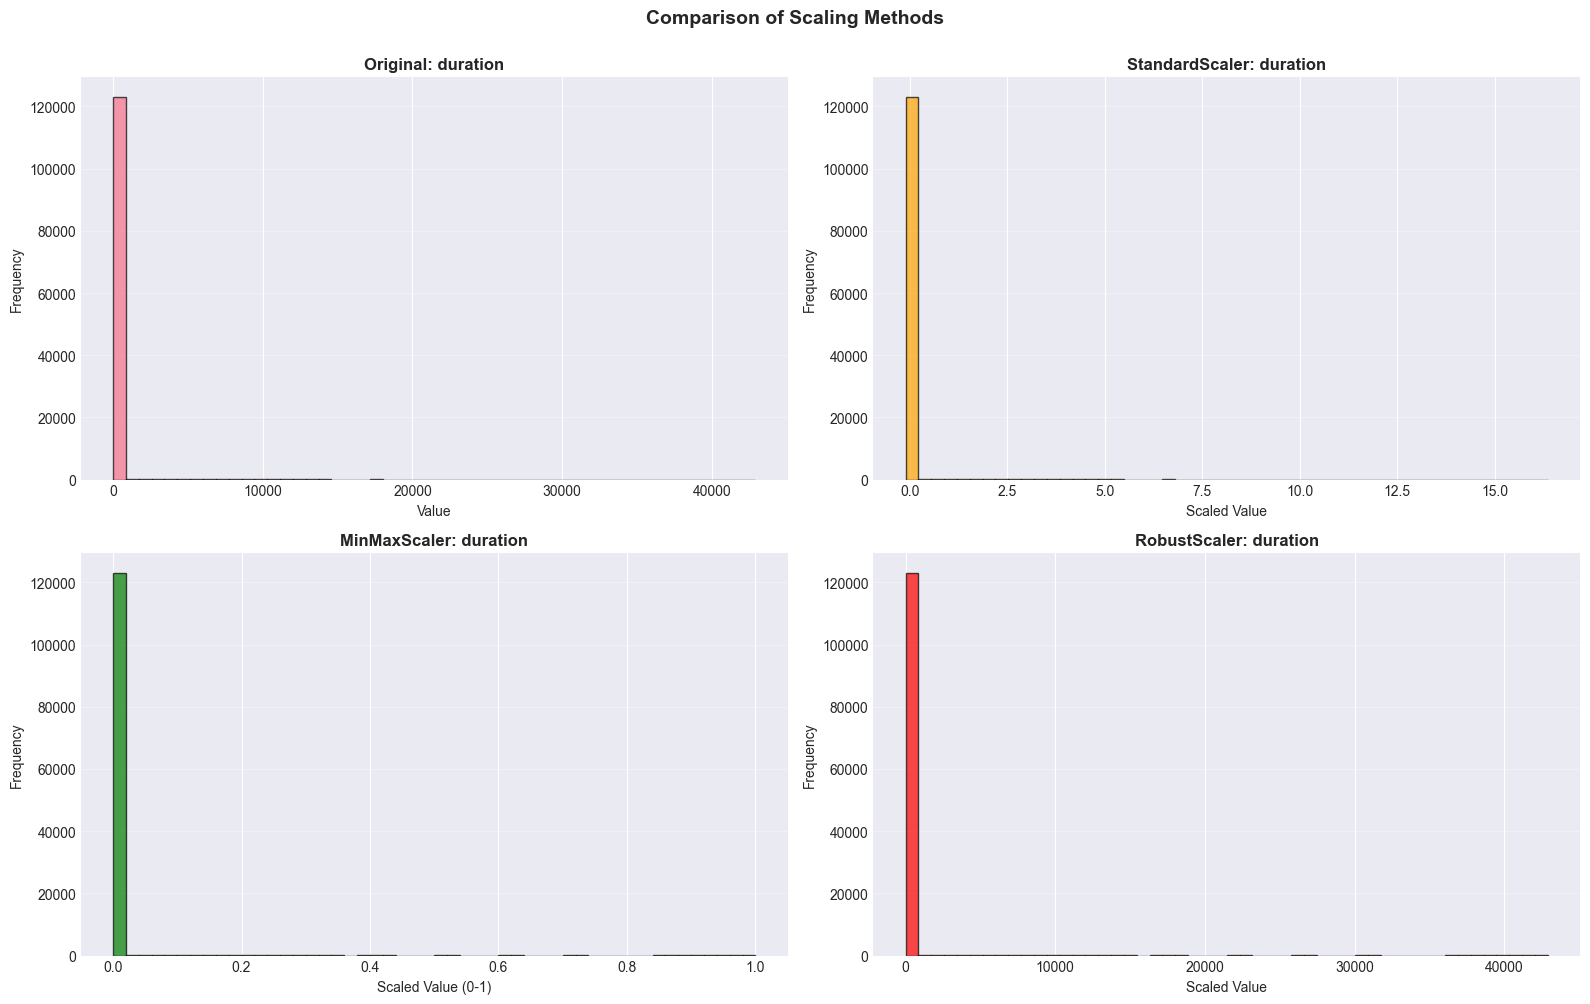

In [20]:
# Visualize scaling comparison
sample_feature_idx = 0  # Duration feature
sample_feature_name = features_to_keep[sample_feature_idx]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

# Original
axes[0].hist(X[:, sample_feature_idx], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Original: {sample_feature_name}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

# StandardScaler
axes[1].hist(X_scaled_standard[:, sample_feature_idx], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title(f'StandardScaler: {sample_feature_name}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Scaled Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3)

# MinMaxScaler
axes[2].hist(X_scaled_minmax[:, sample_feature_idx], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].set_title(f'MinMaxScaler: {sample_feature_name}', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Scaled Value (0-1)')
axes[2].set_ylabel('Frequency')
axes[2].grid(axis='y', alpha=0.3)

# RobustScaler
axes[3].hist(X_scaled_robust[:, sample_feature_idx], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[3].set_title(f'RobustScaler: {sample_feature_name}', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Scaled Value')
axes[3].set_ylabel('Frequency')
axes[3].grid(axis='y', alpha=0.3)

plt.suptitle('Comparison of Scaling Methods', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
## 7. Save Preprocessed Data

In [21]:
# Create dataframes for each scaled version
df_standard = pd.DataFrame(X_scaled_standard, columns=features_to_keep)
df_minmax = pd.DataFrame(X_scaled_minmax, columns=features_to_keep)
df_robust = pd.DataFrame(X_scaled_robust, columns=features_to_keep)

# Add labels back (for evaluation later)
df_standard['attack_category'] = labels.values
df_standard['attack_type'] = attack_types.values

df_minmax['attack_category'] = labels.values
df_minmax['attack_type'] = attack_types.values

df_robust['attack_category'] = labels.values
df_robust['attack_type'] = attack_types.values

print("✓ Scaled dataframes created with labels")

✓ Scaled dataframes created with labels


In [22]:
# Save preprocessed datasets
df_standard.to_csv('nslkdd_scaled_standard.csv', index=False)
df_minmax.to_csv('nslkdd_scaled_minmax.csv', index=False)
df_robust.to_csv('nslkdd_scaled_robust.csv', index=False)

print("✓ Saved: nslkdd_scaled_standard.csv")
print("✓ Saved: nslkdd_scaled_minmax.csv")
print("✓ Saved: nslkdd_scaled_robust.csv")

✓ Saved: nslkdd_scaled_standard.csv
✓ Saved: nslkdd_scaled_minmax.csv
✓ Saved: nslkdd_scaled_robust.csv


In [23]:
# Save feature lists and scalers for reproducibility
import pickle

preprocessing_artifacts = {
    'features_to_keep': features_to_keep,
    'features_removed': all_features_to_remove,
    'low_variance_features': low_variance_features,
    'correlated_features': correlated_features_to_remove,
    'label_encoders': label_encoders,
    'scaler_standard': scaler_standard,
    'scaler_minmax': scaler_minmax,
    'scaler_robust': scaler_robust
}

with open('preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(preprocessing_artifacts, f)

print("✓ Saved: preprocessing_artifacts.pkl")

# Also save as JSON (without scaler objects)
preprocessing_info = {
    'features_to_keep': features_to_keep,
    'features_removed': all_features_to_remove,
    'num_features_original': len(feature_columns),
    'num_features_final': len(features_to_keep),
    'num_features_removed': len(all_features_to_remove)
}

with open('preprocessing_info.json', 'w') as f:
    json.dump(preprocessing_info, f, indent=2)

print("✓ Saved: preprocessing_info.json")

✓ Saved: preprocessing_artifacts.pkl
✓ Saved: preprocessing_info.json


---
## 8. Summary & Next Steps

In [24]:
print("="*80)
print("PREPROCESSING & FEATURE ENGINEERING SUMMARY")
print("="*80)

print(f"\n1. CATEGORICAL ENCODING:")
print(f"   ✓ Label Encoded: {len(categorical_features)} features")
print(f"   ✓ protocol_type: {df['protocol_type'].nunique()} classes")
print(f"   ✓ service: {df['service'].nunique()} classes")
print(f"   ✓ flag: {df['flag'].nunique()} classes")

print(f"\n2. FEATURE SELECTION:")
print(f"   ✓ Original features: {len(feature_columns)}")
print(f"   ✓ Low variance removed: {len(low_variance_features)}")
print(f"   ✓ High correlation removed: {len(correlated_features_to_remove)}")
print(f"   ✓ Final features: {len(features_to_keep)}")
print(f"   ✓ Reduction: {len(all_features_to_remove)} features ({len(all_features_to_remove)/len(feature_columns)*100:.1f}%)")

print(f"\n3. FEATURE SCALING:")
print(f"   ✓ StandardScaler (for PCA, K-Means)")
print(f"   ✓ MinMaxScaler (for distance-based algorithms)")
print(f"   ✓ RobustScaler (for outlier-sensitive algorithms)")

print(f"\n4. SAVED ARTIFACTS:")
print(f"   ✓ nslkdd_scaled_standard.csv")
print(f"   ✓ nslkdd_scaled_minmax.csv")
print(f"   ✓ nslkdd_scaled_robust.csv")
print(f"   ✓ preprocessing_artifacts.pkl")
print(f"   ✓ preprocessing_info.json")

print(f"\n5. DATA READY FOR:")
print(f"   ✓ Dimensionality reduction (PCA, t-SNE, UMAP)")
print(f"   ✓ Clustering (K-Means, DBSCAN, GMM)")
print(f"   ✓ Anomaly detection (Isolation Forest, One-Class SVM)")

print("\n" + "="*80)
print("\n🎯 Ready for Notebook 3: Dimensionality Reduction!")

PREPROCESSING & FEATURE ENGINEERING SUMMARY

1. CATEGORICAL ENCODING:
   ✓ Label Encoded: 3 features
   ✓ protocol_type: 3 classes
   ✓ service: 70 classes
   ✓ flag: 11 classes

2. FEATURE SELECTION:
   ✓ Original features: 41
   ✓ Low variance removed: 10
   ✓ High correlation removed: 7
   ✓ Final features: 24
   ✓ Reduction: 17 features (41.5%)

3. FEATURE SCALING:
   ✓ StandardScaler (for PCA, K-Means)
   ✓ MinMaxScaler (for distance-based algorithms)
   ✓ RobustScaler (for outlier-sensitive algorithms)

4. SAVED ARTIFACTS:
   ✓ nslkdd_scaled_standard.csv
   ✓ nslkdd_scaled_minmax.csv
   ✓ nslkdd_scaled_robust.csv
   ✓ preprocessing_artifacts.pkl
   ✓ preprocessing_info.json

5. DATA READY FOR:
   ✓ Dimensionality reduction (PCA, t-SNE, UMAP)
   ✓ Clustering (K-Means, DBSCAN, GMM)
   ✓ Anomaly detection (Isolation Forest, One-Class SVM)


🎯 Ready for Notebook 3: Dimensionality Reduction!


---
## 📊 Key Takeaways

**What We Did:**
1. ✅ Encoded 3 categorical features using Label Encoding
2. ✅ Removed low-variance features (provide little information)
3. ✅ Removed highly correlated features (redundant)
4. ✅ Created 3 different scaled versions of data
5. ✅ Reduced feature space while preserving information

**Why This Matters:**
- **Fewer features = faster algorithms** (especially important for 125K records)
- **Removes noise** that can hurt unsupervised learning
- **Scaling ensures** algorithms treat all features fairly
- **Multiple scalers** let us choose best for each algorithm

**Next:** 
We'll use PCA to reduce from ~35 features to ~10 principal components while retaining 95%+ variance!